Primeras filas del dataset:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Resumen de estadísticas descriptivas:
               step        amount  old

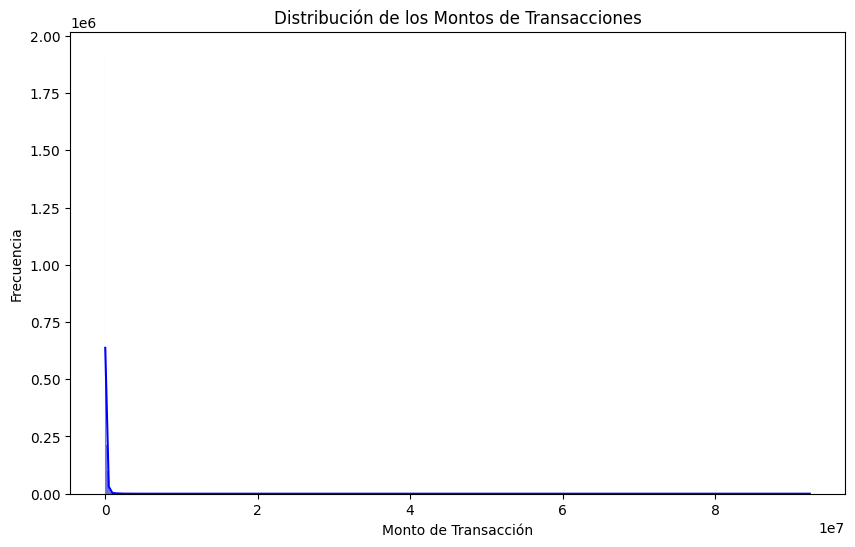

In [2]:
# demo_search.ipynb

# Importar librerías necesarias
import pandas as pd
import heapq
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
def load_data(file_path):
    """
    Función para cargar y explorar los datos del dataset de transacciones.
    """
    data = pd.read_csv(file_path)  # Asumiendo que el dataset está en formato CSV
    print("Primeras filas del dataset:")
    print(data.head())
    print("\nResumen de estadísticas descriptivas:")
    print(data.describe())
    return data

# Heurística para el algoritmo A*
def heuristic(transaction):
    """
    Heurística para el algoritmo A*. En este caso, la heurística podría basarse en el monto de la transacción,
    la frecuencia de transacciones del cliente y otras características sospechosas.
    """
    return transaction['amount'] * 0.1  # Ejemplo: más alto es más sospechoso

# Función de vecinos
def get_neighbors(current_transaction, transactions):
    """
    Obtiene las transacciones cercanas (simula la expansión de nodos en el espacio de estados).
    """
    neighbors = []
    for transaction in transactions:
        if transaction != current_transaction:
            neighbors.append(transaction)
    return neighbors

# Algoritmo A* para la detección de fraudes
def a_star_search(transactions):
    """
    Algoritmo A* para la detección de fraudes en las transacciones.
    """
    open_list = []
    count = 0 # Contador para desempatar elementos con el mismo costo en el heapq
    heapq.heappush(open_list, (0 + heuristic(transactions[0]), 0, count, transactions[0]))  # (f(n), g(n), contador, transacción)
    closed_list = set()

    while open_list:
        current_f, current_g, _, current_transaction = heapq.heappop(open_list)

        # Si encontramos una transacción fraudulenta
        if current_transaction['isFraud'] == 1:
            return current_transaction  # Se encontró una transacción fraudulenta

        # Guardamos como tupla ya que los diccionarios no son hasheables
        closed_list.add(tuple(current_transaction.items()))

        for neighbor in get_neighbors(current_transaction, transactions):
            if tuple(neighbor.items()) not in closed_list:
                cost = current_g + 1
                count += 1
                heapq.heappush(open_list, (cost + heuristic(neighbor), cost, count, neighbor))

    return None

# Cargar el dataset
dataset_path = "C:\\Users\\cgalv\\source\\Python\\AI\\financial_data_set\\Synthetic_Financial_datasets_log.csv"  # Ruta proporcionada
data = load_data(dataset_path)

# Realizar la búsqueda de fraude utilizando A*
fraudulent_transaction = a_star_search(data.to_dict(orient="records"))

# Mostrar el resultado
if fraudulent_transaction:
    print("Transacción fraudulenta encontrada:")
    print(fraudulent_transaction)
else:
    print("No se encontraron transacciones fraudulentas.")

# Visualización de las transacciones por monto
plt.figure(figsize=(10, 6))
sns.histplot(data['amount'], kde=True, color='blue')
plt.title("Distribución de los Montos de Transacciones")
plt.xlabel("Monto de Transacción")
plt.ylabel("Frecuencia")
plt.show()